In [20]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from adjustText import adjust_text
import math
from scipy.stats import spearmanr
from ete3 import Tree
from tqdm import tqdm
from sklearn.metrics import roc_auc_score,roc_curve

In [2]:
params = "hfq.200.100--Enterobacterales-gtdb/pair.zscore-0.7_hfq.Z-0.3_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1"
path = f"output/Enterobacteriaceae/comparative-analysis-denoised-ml/{params}/GcvB.txt"
table = pd.read_csv(path,sep="\t")

In [3]:
table = table[table["tree"] != "."].loc[:,["query id","tree"]]
table.index = table["query id"].map(lambda x:"-".join(x.split("-")[2:]))
nwk = "output/Enterobacteriaceae/phylogeny/Enterobacterales-gtdb/rpoB.nwk"
orig = Tree(nwk, format=1)
mroot = orig.get_midpoint_outgroup()
orig.set_outgroup(mroot)
leaf_names = orig.get_leaf_names()
# label leave node of the full tree
leaf2idx = {name: i for i, name in enumerate(leaf_names)}

In [4]:
params = "hfq.200.100--Enterobacterales-gtdb/pair.zscore-0.7_hfq.Z-0.3_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1"
path = f"output/Enterobacteriaceae/comparative-analysis-denoised-ml/{params}/GcvB/raw-quantile.txt"
raw_quantiles = pd.read_csv(path,sep="\t",index_col=0)
path = f"output/Enterobacteriaceae/comparative-analysis-denoised-ml/{params}/GcvB/denoised-quantile.txt"
denoised_quantiles = pd.read_csv(path,sep="\t",index_col=0)

In [5]:
params = "hfq.200.100--Enterobacterales-gtdb/pair.zscore-0.0_hfq.Z-1.0_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1"
path = f"output/Enterobacteriaceae/comparative-analysis-denoised-ml/{params}/GcvB/raw-quantile.txt"
hfq_raw_quantiles = pd.read_csv(path,sep="\t",index_col=0)
path = f"output/Enterobacteriaceae/comparative-analysis-denoised-ml/{params}/GcvB/denoised-quantile.txt"
hfq_denoised_quantiles = pd.read_csv(path,sep="\t",index_col=0)

In [6]:
common_gene_ids = np.intersect1d(denoised_quantiles.index,hfq_denoised_quantiles.index)

In [7]:
protein_ids = []
with open("benchmark/leader/GCF_000005845.2/GcvB.txt") as f:
    for line in f:
        fields = line[:-1].split("\t")
        if "validated" in fields[1]:
            protein_ids.append(fields[0])

In [8]:
raw_scores = pd.read_csv("test.gcvB/raw-zscore.txt",sep="\t",index_col=0)
raw_scores.index = raw_scores.index.map(lambda x:"-".join(x.split("-")[2:]))
denoised_scores = pd.read_csv("test.gcvB/denoised-zscore.txt",sep="\t",index_col=0)
denoised_scores.index = denoised_scores.index.map(lambda x:"-".join(x.split("-")[2:]))
denoised_scores = denoised_scores[~denoised_scores.index.duplicated()]
stats = pd.read_csv("test.gcvB/stats.txt",sep="\t")
stats = stats.set_index("gene id")
stats["denoised score"] = denoised_scores.loc[:,"GCF_000005845.2"].loc[stats.index.map(lambda x:"-".join(x.split("-")[2:]))].values
#stats = stats.set_index("gene id")
stats["validated"] = stats.index.map(lambda x:x.split(":")[1].split("-")[0] in protein_ids)
stats["denoised percentile"] = stats["denoised score"].rank(ascending=False)/stats.shape[0]
stats.loc[:,"denoised percentile"] = stats["denoised score"].rank(ascending=True)/stats.shape[0]
stats.loc[:,"root percentile"] = stats["root score"].rank(ascending=True)/stats.shape[0]
stats["denoised score"] = (stats["denoised score"]-stats["denoised score"].mean())/stats["denoised score"].std()
stats["root score"] = (stats["root score"]-stats["root score"].mean())/stats["root score"].std()

/BioII/lulab_b/jinyunfan/miniforge3/envs/rna-analysis/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


Text(14.222222222222223, 0.5, 'Change relative to root')

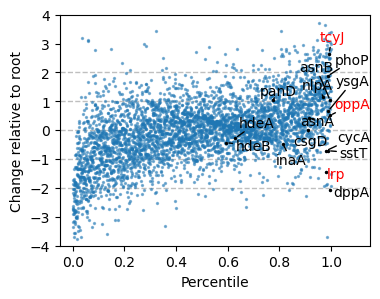

In [9]:
fig, ax = plt.subplots(figsize=(4,3))
ax.scatter(stats["denoised percentile"],stats["denoised score"]-stats["root score"],s=2,alpha=0.5)
validated_stats = stats[stats["validated"]]
validated_stats["names"] = validated_stats.index.map(lambda x:x.split(":")[-1].split("-")[-1])
xs = validated_stats["denoised percentile"].values
ys = validated_stats["denoised score"]-validated_stats["root score"]
names = validated_stats["names"].values
ax.set_ylim([-4,4])
ax.set_xlim([-0.05,1.15])
texts = []
ax.scatter(xs,ys,color="black",s=2)
for i in range(len(validated_stats.index)):
    if names[i] in ["tcyJ","oppA","lrp"]:
        texts.append(ax.text(x=xs[i],y=ys[i],s=names[i],color="red"))
    else:
        texts.append(ax.text(x=xs[i],y=ys[i],s=names[i]))
ax.plot([-0.05,1.2],[-1,-1],linestyle="--",linewidth=1,color="gray",alpha=0.5,zorder=-1)
ax.plot([-0.05,1.2],[1,1],linestyle="--",linewidth=1,color="gray",alpha=0.5,zorder=-1)
ax.plot([-0.05,1.2],[-2,-2],linestyle="--",linewidth=1,color="gray",alpha=0.5,zorder=-1)
ax.plot([-0.05,1.2],[2,2],linestyle="--",linewidth=1,color="gray",alpha=0.5,zorder=-1)
ax.plot([-0.05,1.2],[0,0],linestyle="--",linewidth=1,color="gray",alpha=0.5,zorder=-1)
adjust_text(texts, 
            arrowprops=dict(arrowstyle='-'))    
ax.set_xlabel("Percentile")
ax.set_ylabel("Change relative to root")

In [10]:
nonna_fraction = (~denoised_scores.isna()).sum(axis=1)/denoised_scores.shape[1]
conserved_gene_ids = nonna_fraction[nonna_fraction>0.5].index
stats.index = stats.index.map(lambda x:"-".join(x.split("-")[2:]))
stats = stats[~stats.index.duplicated()]

Text(12.597222222222223, 0.5, 'Standard deviation')

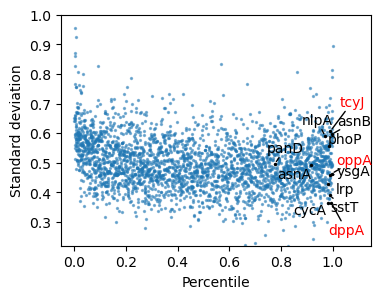

In [11]:
fig, ax = plt.subplots(figsize=(4,3))
conserved_stats = stats.loc[conserved_gene_ids,:]
conserved_stats["std"] = denoised_scores.std(axis=1).loc[conserved_gene_ids]
ax.scatter(conserved_stats["denoised percentile"],conserved_stats["std"],s=2,alpha=0.5)
validated_stats = conserved_stats[conserved_stats["validated"]]
validated_stats_used = validated_stats[validated_stats.index.map(lambda x:x in conserved_gene_ids)]
xs = validated_stats_used["denoised percentile"].values
ys = validated_stats_used["std"]
names = validated_stats.index
#ax.set_ylim([-4,4])
ax.set_xlim([-0.05,1.15])
ax.set_ylim([0.22,1.0])
texts = []
ax.scatter(xs,ys,color="black",s=2)
for i in range(len(validated_stats_used.index)):
    if names[i] in ["tcyJ","oppA","dppA"]:
        texts.append(ax.text(x=xs[i],y=ys[i],s=names[i],color="red"))
    else:
        texts.append(ax.text(x=xs[i],y=ys[i],s=names[i]))
adjust_text(texts, 
            arrowprops=dict(arrowstyle='-'))    
ax.set_xlabel("Percentile")
ax.set_ylabel("Standard deviation")

/BioII/lulab_b/jinyunfan/miniforge3/envs/rna-analysis/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


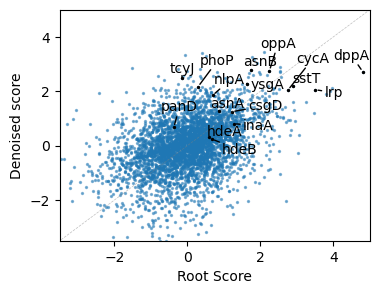

In [12]:
fig, ax = plt.subplots(figsize=(4,3))
ax.scatter(stats["root score"].values,stats["denoised score"],s=2,alpha=0.5)
validated_stats = stats[stats["validated"]]
validated_stats["names"] = validated_stats.index.map(lambda x:x.split(":")[-1].split("-")[-1])
xs = validated_stats["root score"].values
ys = validated_stats["denoised score"].values
names = validated_stats["names"].values
ax.set_xlim([-3.5,5.0])
ax.set_ylim([-3.5,5.0])
texts = []
ax.scatter(xs,ys,color="black",s=2)   
ax.set_xlabel("Root Score")
ax.set_ylabel("Denoised score")
ax.plot([-5,5],[-5,5],lw=0.5,linestyle="--",color="gray",alpha=0.5)
for i in range(len(validated_stats.index)):
    texts.append(ax.text(x=xs[i],y=ys[i],s=names[i]))
_ = adjust_text(texts, 
            arrowprops=dict(arrowstyle='-')) 

In [553]:
gene_id = "tcyJ"
#gene_id = "oppA"
fout = open(f"GcvB-example-targets/{gene_id}.fa","w")
for path in glob("output/Enterobacteriaceae/*/leader.fa"):
    asm_id = path.split("/")[-2]
    with open(path) as f:
        for header in f:
            sequence = next(f)
            if header.strip().endswith("-" + gene_id):
                print(">" + asm_id + ":" + header.strip()[1:],file=fout)
                print(sequence.strip(),file=fout)
fout.close()

In [ ]:
lines = """DATASET_SIMPLEBAR
SEPARATOR COMMA
DATASET_LABEL,raw score
COLOR,#ff0000
DATA
"""
scores = raw_scores
scores = scores.rank(axis=0)/scores.shape[0]
for gene_id in ["phoP"]:#["tcyJ","oppA"]:
    gene_scores = scores.loc[gene_id]
    for genome_id in gene_scores.keys():
        lines += f"{genome_id},{gene_scores[genome_id]}\n"
    with open(f"GcvB-example-targets/{gene_id}.raw.txt","w") as f:
        f.write(lines)

In [101]:
lines = """DATASET_SIMPLEBAR
SEPARATOR COMMA
DATASET_LABEL,denoised score
COLOR,#00ff00
DATA
"""
scores = denoised_scores
scores = scores.rank(axis=0)/scores.shape[0]
for gene_id in ["phoP"]:#["tcyJ","oppA"]:
    gene_scores = scores.loc[gene_id]
    for genome_id in gene_scores.keys():
        lines += f"{genome_id},{gene_scores[genome_id]}\n"
    with open(f"GcvB-example-targets/{gene_id}.denoised.txt","w") as f:
        f.write(lines)

In [14]:
raw_score_path = "output/Enterobacteriaceae/comparative-analysis-denoised-ml/hfq.200.100--Enterobacterales-gtdb/pair.zscore-0.0_hfq.Z-1.0_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1/GcvB/raw-zscore.txt"
denoised_score_path = "output/Enterobacteriaceae/comparative-analysis-denoised-ml/hfq.200.100--Enterobacterales-gtdb/pair.zscore-0.0_hfq.Z-1.0_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1/GcvB/denoised-zscore.txt"
stats_path = "output/Enterobacteriaceae/comparative-analysis-denoised-ml/hfq.200.100--Enterobacterales-gtdb/pair.zscore-0.0_hfq.Z-1.0_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1/GcvB/stats.txt"

In [16]:
raw_scores = pd.read_csv(raw_score_path,sep="\t",index_col=0)
raw_scores.index = raw_scores.index.map(lambda x:x.split("-")[-1])
raw_scores = raw_scores[~raw_scores.index.duplicated()]
denoised_scores = pd.read_csv(denoised_score_path,sep="\t",index_col=0)
denoised_scores.index = denoised_scores.index.map(lambda x:x.split("-")[-1])
denoised_scores = denoised_scores[~denoised_scores.index.duplicated()]

In [17]:
stats = pd.read_csv(stats_path,sep="\t")
stats = stats.set_index("gene id")

In [19]:
validated_protein_ids = open("benchmark/leader/GCF_000005845.2.validated.targets.txt").read().strip().split("\n")
validated_protein_ids = set(validated_protein_ids)
stats["raw score"] = raw_scores.loc[:,"GCF_000005845.2"].loc[stats.index.map(lambda x:x.split("-")[-1])].values
stats["denoised score"] = denoised_scores.loc[:,"GCF_000005845.2"].loc[stats.index.map(lambda x:x.split("-")[-1])].values
stats["validated"] = stats.index.map(lambda x:x.split(":")[1].split("-")[0] in validated_protein_ids)

In [23]:
mask = (~denoised_scores.loc[stats.index.map(lambda x:x.split("-")[-1])].isna()).sum(axis=1)/denoised_scores.shape[1] < 1.1
mask = mask.values

In [24]:
stats["denoised score"] = (stats["denoised score"] - stats["denoised score"].mean())/stats["denoised score"].std()
stats["raw score"] = (stats["raw score"] - stats["raw score"].mean())/stats["raw score"].std()
stats["root score"] = (stats["root score"] - stats["root score"].mean())/stats["root score"].std()

In [25]:
stats.loc[:,"denoised percentile"] = stats["denoised score"].rank(ascending=True)/stats.shape[0]
stats.loc[:,"root percentile"] = stats["root score"].rank(ascending=True)/stats.shape[0]

In [27]:
from collections import defaultdict
from glob import glob
import os

In [28]:
def plot_known_targets(sRNA_id):
    genome_id = "GCF_000005845.2"
    indir = f"output/Enterobacteriaceae/comparative-analysis-denoised-ml/hfq.200.100--Enterobacterales-gtdb/pair.zscore-0.7_hfq.Z-0.3_normalize-1_marker-rpoB_srm-10_nvm-10_rescale-0_reroot-1/{sRNA_id}"
    stats = pd.read_csv(os.path.join(indir,"stats.txt"),index_col=0,sep="\t")
    denoised_scores = pd.read_csv(os.path.join(indir,"denoised-zscore.txt"),index_col=0,sep="\t")
    validated_targets = set()
    if sRNA_id != "CpxQ":
        with open(f"benchmark/leader/{genome_id}/{sRNA_id}.txt") as f:
            for line in f:
                fields = line.strip().split("\t")
                if "validated" in fields[1]:
                    validated_targets.add(fields[0])
        #if sRNA_id == "GcvB":
        #    validated_targets.add("NP_416051.1")
    else:
        #validated_targets = set(["nhaB","skp","agp","fimA","cfa"])
        validated_targets = set(["NP_415704.1","NP_414720.1","NP_415522.1","NP_418734.1","NP_416178.1"]) 
        
    conserved_fractions = (~denoised_scores.isna()).sum(axis=1)/denoised_scores.shape[1]
    conserved_gene_ids = conserved_fractions[conserved_fractions>0.5].index
    ranks = denoised_scores[genome_id].rank(axis=0)/denoised_scores.shape[0] #(~denoised_scores.isna()).sum(axis=1).values.reshape(-1,1)
    stats["denoised percentile"] = ranks.loc[stats.index]
    fig, ax = plt.subplots(figsize=(4,3))
    conserved_stats = stats.loc[conserved_gene_ids]
    conserved_stats["validated"] = conserved_stats.index.map(lambda x:x.split(":")[1].split("-")[0]).isin(validated_targets)
    ax.scatter(conserved_stats["denoised percentile"],conserved_stats["std"],s=2,alpha=0.5)

    validated_stats = conserved_stats[conserved_stats["validated"]]
    xs = validated_stats["denoised percentile"].values
    ys = validated_stats["std"]

    texts = []
    ax.scatter(xs,ys,color="black",s=2)
    #ax.set_xlim([0.9,1.0])
    names = validated_stats.index.map(lambda x:"-".join(x.split("-")[2:]))
    for i in range(len(names)):
        texts.append(ax.text(x=xs[i],y=ys[i],s=names[i]))
    adjust_text(texts, 
                arrowprops=dict(arrowstyle='-'))    
    ax.set_xlabel("Percentile")
    ax.set_ylabel("Standard deviation")
    ax.set_title(sRNA_id)

In [5]:
sRNA_ids = ["CyaR", "DsrA", "FnrS", "MicA", "OmrA", "OmrB", "OxyS", "RprA", "RybA", "RybB", "RyhB", "SdsR", "SgrS", "Spot42"]

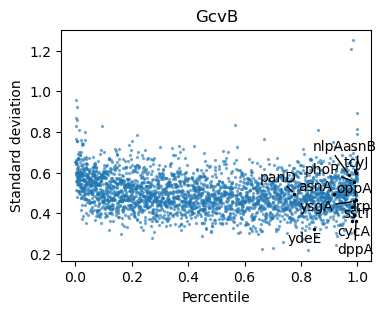

In [105]:
plot_known_targets("GcvB")

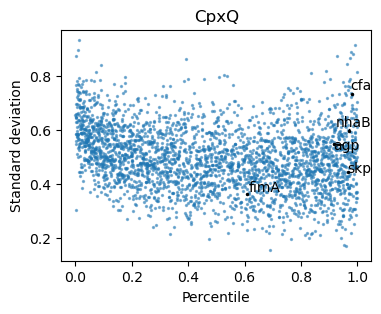

In [18]:
for sRNA_id in ["CpxQ"]:
    plot_known_targets(sRNA_id)
    plt.savefig(f"ecoli-conservation-example/{sRNA_id}.pdf",bbox_inches="tight")